In [1]:
!ls processed_bert

X_bert.npy                X_nrc_features_scaled.npy
X_combined.npy            y.npy


In [2]:
data_dir = 'processed_bert'
X_combined_file = 'X_combined.npy'
y_file = 'y.npy'

In [3]:
import numpy as np
from os import path
import pandas as pd

X_combined_dataset = np.load(path.join(data_dir, X_combined_file))
y_resampled = np.load(path.join(data_dir, y_file))
y_resampled = pd.Series(y_resampled)

In [4]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X_combined_dataset, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

print(f'X_train shape: {X_train_val.shape}')
print(f'y_train shape: {y_train_val.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

print(f'y_train count:\n{y_train_val.value_counts()}')
print(f'y_test count:\n{y_test.value_counts()}')

X_train shape: (79672, 394)
y_train shape: (79672,)
X_test shape: (19918, 394)
y_test shape: (19918,)
y_train count:
0    46724
1    32948
Name: count, dtype: int64
y_test count:
0    11681
1     8237
Name: count, dtype: int64


In [5]:
import tensorflow as tf

# BERT embeddings are dense numpy arrays — no custom data generator needed.
# Keras accepts dense arrays directly in fit/evaluate/predict.
print(f"TensorFlow version: {tf.__version__}")
print(f"X_combined_dataset dtype: {X_combined_dataset.dtype}, shape: {X_combined_dataset.shape}")

TensorFlow version: 2.16.1
X_combined_dataset dtype: float64, shape: (99590, 394)


In [6]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_val_resampled, y_train_val_resampled = ros.fit_resample(X_train_val, y_train_val)
print(f'X_train_val_resampled shape: {X_train_val_resampled.shape}')
print(f'y_train_val_resampled shape: {y_train_val_resampled.shape}')
print(f'y_train_val_resampled count:\n{y_train_val_resampled.value_counts()}')

X_train_val_resampled shape: (93448, 394)
y_train_val_resampled shape: (93448,)
y_train_val_resampled count:
1    46724
0    46724
Name: count, dtype: int64


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val_resampled, y_train_val_resampled,
    test_size=0.2, stratify=y_train_val_resampled, random_state=42
)

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    
    # Add batch normalization at input
    model.add(layers.BatchNormalization())

    # Increase depth and width options
    for i in range(hp.Int('num_layers', min_value=2, max_value=5)):
        model.add(
            layers.Dense(
                units=hp.Int(f'units_hidden_{i}', min_value=64, max_value=768, step=64), 
                activation=hp.Choice(f'activation_hidden_{i}', values=['relu', 'tanh', 'elu'])
            )
        )
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(rate=hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))

    # Tune the optimizer - add SGD with momentum
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='log')
    
    if optimizer_choice == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [9]:
from keras_tuner import Hyperband

PROJECT_NAME = 'reddit_mlp_bert_nrclex_v2'
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    hyperband_iterations=2,
    directory='keras_mlp',
    project_name=PROJECT_NAME,
    overwrite=False  # IMPORTANT: keep False to resume from previous crashed run
)


2026-03-05 20:45:05.508060: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-05 20:45:05.508101: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-05 20:45:05.508109: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-05 20:45:05.508150: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-05 20:45:05.508160: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Reloading Tuner from keras_mlp/reddit_mlp_bert_nrclex_v2/tuner0.json


In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Re-running this cell will continue pending tuner trials when overwrite=False.
tuner.search(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
 )

Trial 180 Complete [00h 07m 15s]
val_accuracy: 0.8262707591056824

Best val_accuracy So Far: 0.8863563537597656
Total elapsed time: 1d 05h 00m 53s


In [11]:
# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the best hyperparameters
model = build_model(best_hps)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_4           │ (None, 394)            │         1,576 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 704)            │       278,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 704)            │         2,816 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 704)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 704)            │       496,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 704)            │         2,816 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 704)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 768)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 880,745 (3.36 MB)

 Trainable params: 875,477 (3.34 MB)

 Non-trainable params: 5,268 (20.58 KB)

Epoch 1/200
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.8118 - loss: 0.4140 - val_accuracy: 0.8509 - val_loss: 0.3401 - learning_rate: 9.1544e-04
Epoch 2/200
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.8385 - loss: 0.3573 - val_accuracy: 0.8492 - val_loss: 0.3321 - learning_rate: 9.1544e-04
Epoch 3/200
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.8459 - loss: 0.3432 - val_accuracy: 0.8551 - val_loss: 0.3167 - learning_rate: 9.1544e-04
Epoch 4/200
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.8527 - loss: 0.3319 - val_accuracy: 0.8618 - val_loss: 0.3125 - learning_rate: 9.1544e-04
Epoch 5/200
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.8555 - loss: 0.3230 - val_accuracy: 0.8616 - val_loss: 0.3096 - learning_rate: 9.1544e-04
Epoch 6/200
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.8605 - loss: 0.3153 - val_accuracy: 0.8651 - val_loss: 0.3231 - learning_rate: 9.1544e-04
Epoch 7/200
2337/2337 ━━━━━━━━━━━━

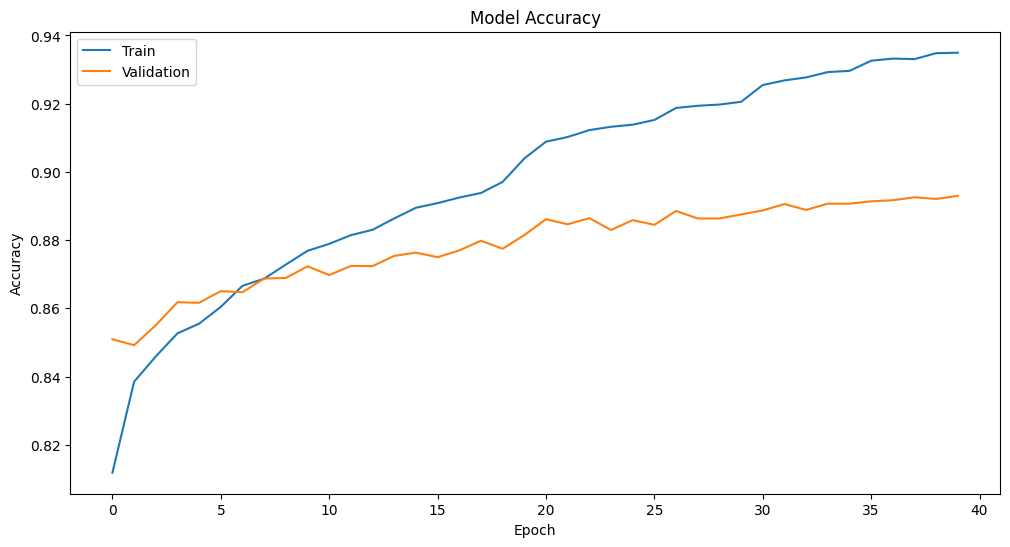

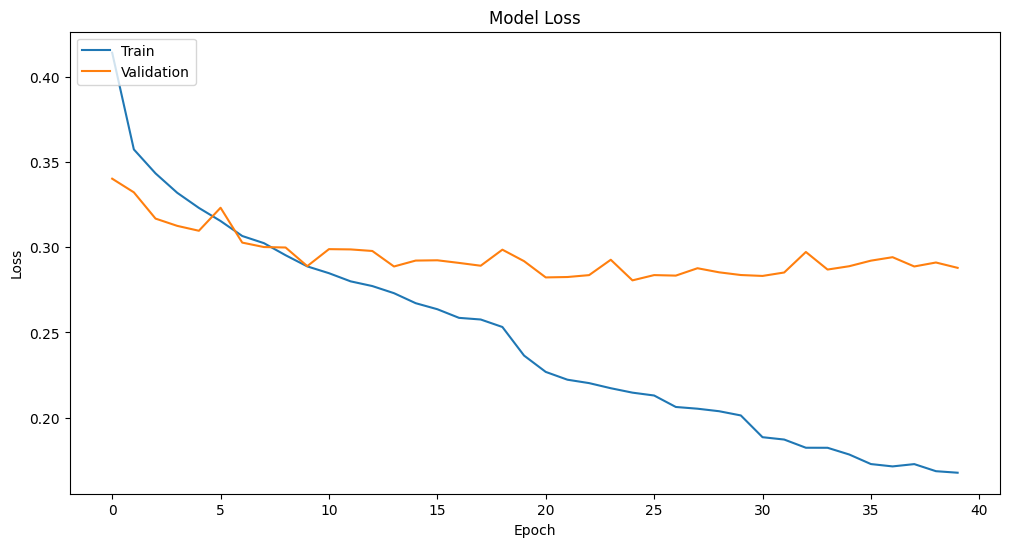

In [12]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,  # Increased patience
    restore_best_weights=True
)

# Add learning rate reduction
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=200, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr]
)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [13]:
best_epoch_num = np.argmin(history.history['val_loss']) + 1

print(f'Best epoch found: {best_epoch_num}')

final_model = build_model(best_hps)

final_model.fit(X_train_val_resampled, y_train_val_resampled,
                epochs=best_epoch_num, batch_size=32, verbose=True)

Best epoch found: 25
Epoch 1/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - accuracy: 0.8148 - loss: 0.4065
Epoch 2/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8402 - loss: 0.3546
Epoch 3/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8485 - loss: 0.3400
Epoch 4/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8532 - loss: 0.3305
Epoch 5/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8565 - loss: 0.3232
Epoch 6/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8622 - loss: 0.3134
Epoch 7/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8643 - loss: 0.3091
Epoch 8/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8683 - loss: 0.3030
Epoch 9/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8706 - loss: 0.2977
Epoch 10/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8732 - loss: 0.2939
Epoch 11/25
2921/2921 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.8749 - 

In [14]:
loss, accuracy = final_model.evaluate(X_test, y_test.values, batch_size=32)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8610 - loss: 0.3210
Test Loss: 0.3210
Test Accuracy: 0.8610


623/623 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88     11681
           1       0.82      0.85      0.84      8237

    accuracy                           0.86     19918
   macro avg       0.86      0.86      0.86     19918
weighted avg       0.86      0.86      0.86     19918



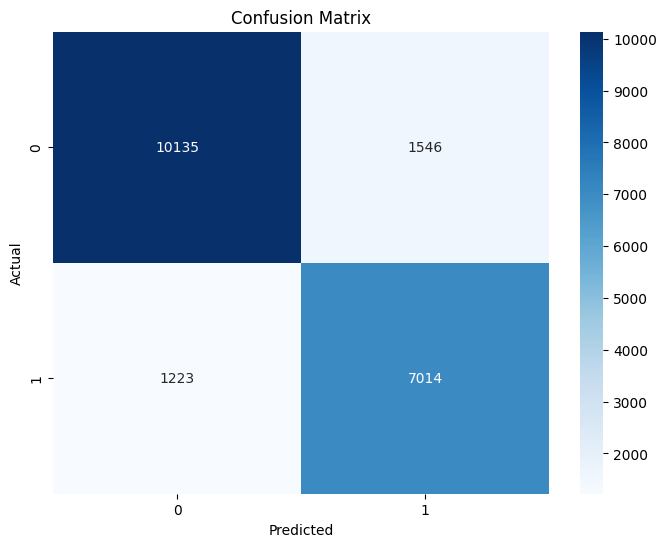

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_probs = final_model.predict(X_test, batch_size=32)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

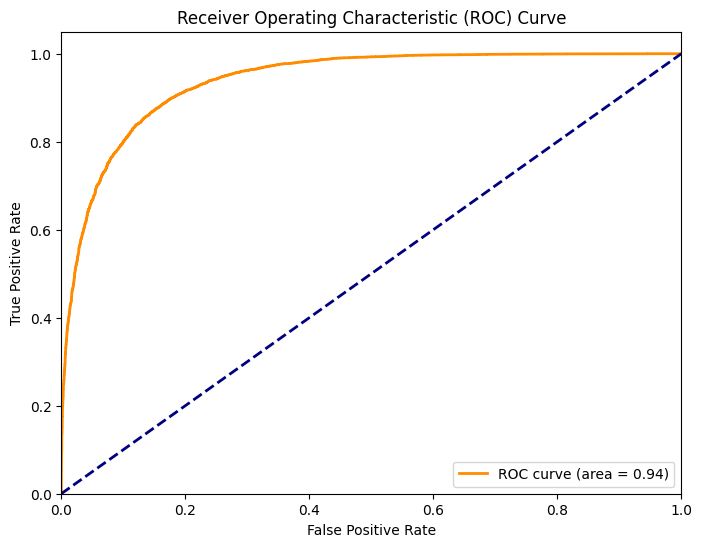

In [16]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

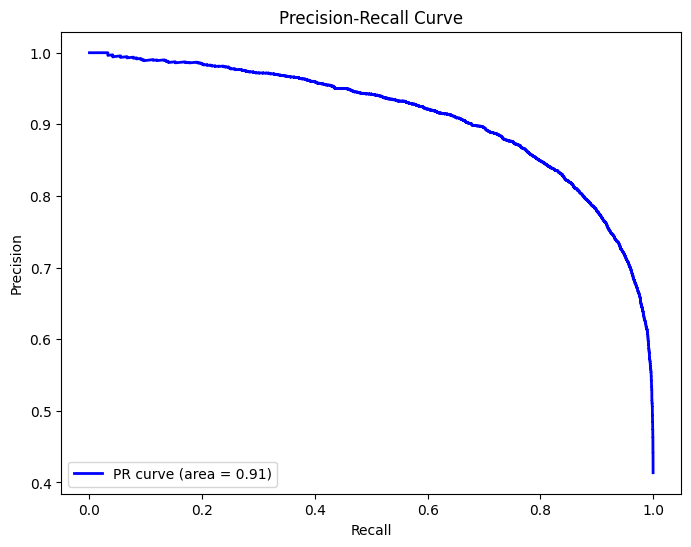

In [17]:
# Calculate PR curve and Average Precision
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
average_precision = average_precision_score(y_test, y_pred_probs)

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='PR curve (area = %0.2f)' % average_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [18]:
import os
model_directory='models'
if not os.path.exists(model_directory):
    os.makedirs(model_directory)
model_name=f'{PROJECT_NAME}.keras'
final_model.save(path.join(model_directory, model_name))